In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (roc_auc_score, roc_curve, f1_score, precision_recall_curve,
                               classification_report, confusion_matrix, auc)

import xgboost as xgb
from xgboost import XGBClassifier

pd.set_option('display.max_columns', None)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df=pd.read_csv('/content/drive/MyDrive/14 Days of ML/XGBoost+Gradiant Boosting_Day6/accepted_2007_to_2018Q4.csv')
df.head()

/tmp/ipykernel_990/3071233713.py:1: DtypeWarning: Columns (0,19,49,59,118,129,130,131,134,135,136,139,145,146,147) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv('/content/drive/MyDrive/14 Days of ML/XGBoost+Gradiant Boosting_Day6/accepted_2007_to_2018Q4.csv')


In [4]:
# Pehle sirf column names dekho, poora data load kiye bina
cols = pd.read_csv('/content/drive/MyDrive/14 Days of ML/XGBoost+Gradiant Boosting_Day6/accepted_2007_to_2018Q4.csv', nrows=0).columns.tolist()
print(len(cols))
print(cols)

151
['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'url', 'desc', 'purpose', 'title', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'policy_code', 'application_type', 'annual_inc_joint', 'dti_joint', 'verification_status_joint', 'acc_now_deli

In [5]:
# Display all available columns
for i, col in enumerate(cols):
    print(f"{i}: {col}")

0: id
1: member_id
2: loan_amnt
3: funded_amnt
4: funded_amnt_inv
5: term
6: int_rate
7: installment
8: grade
9: sub_grade
10: emp_title
11: emp_length
12: home_ownership
13: annual_inc
14: verification_status
15: issue_d
16: loan_status
17: pymnt_plan
18: url
19: desc
20: purpose
21: title
22: zip_code
23: addr_state
24: dti
25: delinq_2yrs
26: earliest_cr_line
27: fico_range_low
28: fico_range_high
29: inq_last_6mths
30: mths_since_last_delinq
31: mths_since_last_record
32: open_acc
33: pub_rec
34: revol_bal
35: revol_util
36: total_acc
37: initial_list_status
38: out_prncp
39: out_prncp_inv
40: total_pymnt
41: total_pymnt_inv
42: total_rec_prncp
43: total_rec_int
44: total_rec_late_fee
45: recoveries
46: collection_recovery_fee
47: last_pymnt_d
48: last_pymnt_amnt
49: next_pymnt_d
50: last_credit_pull_d
51: last_fico_range_high
52: last_fico_range_low
53: collections_12_mths_ex_med
54: mths_since_last_major_derog
55: policy_code
56: application_type
57: annual_inc_joint
58: dti_join

In [6]:
# Selected features for Loan Default Prediction

selected_columns = [
    'loan_amnt',
    'term',
    'int_rate',
    'installment',
    'grade',
    'sub_grade',
    'emp_length',
    'home_ownership',
    'annual_inc',
    'verification_status',
    'purpose',
    'dti',
    'delinq_2yrs',
    'earliest_cr_line',
    'fico_range_low',
    'fico_range_high',
    'inq_last_6mths',
    'open_acc',
    'pub_rec',
    'revol_bal',
    'revol_util',
    'total_acc',
    'initial_list_status',
    'application_type',
    'mort_acc',
    'pub_rec_bankruptcies',
    'tax_liens'
]

target_column = 'loan_status'

print("Number of features:", len(selected_columns))
print("\nSelected features:")
print(selected_columns)

print("\nTarget:", target_column)

Number of features: 27

Selected features:
['loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'purpose', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'application_type', 'mort_acc', 'pub_rec_bankruptcies', 'tax_liens']

Target: loan_status


In [7]:
# Loading only selected columns + target
usecols = selected_columns + [target_column]

df = pd.read_csv(
    '/content/drive/MyDrive/14 Days of ML/XGBoost+Gradiant Boosting_Day6/accepted_2007_to_2018Q4.csv',
    usecols=usecols,
    nrows=300000,
    low_memory=False
)

print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset Shape: (300000, 28)

Columns:
['loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'loan_status', 'purpose', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'application_type', 'mort_acc', 'pub_rec_bankruptcies', 'tax_liens']


In [8]:
# Checking the loan status distribution

print("Loan Status Counts:")
print(df['loan_status'].value_counts(dropna=False))

print("\nLoan Status Percentages:")
print(df['loan_status'].value_counts(normalize=True, dropna=False) * 100)

Loan Status Counts:
loan_status
Fully Paid            212275
Charged Off            53501
Current                32462
Late (31-120 days)      1063
In Grace Period          483
Late (16-30 days)        215
Default                    1
Name: count, dtype: int64

Loan Status Percentages:
loan_status
Fully Paid            70.758333
Charged Off           17.833667
Current               10.820667
Late (31-120 days)     0.354333
In Grace Period        0.161000
Late (16-30 days)      0.071667
Default                0.000333
Name: proportion, dtype: float64


In [9]:
# Keeping only loans with a known final outcome

final_statuses = ['Fully Paid', 'Charged Off', 'Default']

df = df[df['loan_status'].isin(final_statuses)].copy()

# Creating binary target
df['default'] = df['loan_status'].map({
    'Fully Paid': 0,
    'Charged Off': 1,
    'Default': 1
})

print("Dataset Shape:", df.shape)

print("\nTarget Distribution:")
print(df['default'].value_counts())

print("\nTarget Percentages:")
print(df['default'].value_counts(normalize=True) * 100)

print("\nMissing Target Values:", df['default'].isnull().sum())

Dataset Shape: (265777, 29)

Target Distribution:
default
0    212275
1     53502
Name: count, dtype: int64

Target Percentages:
default
0    79.86959
1    20.13041
Name: proportion, dtype: float64

Missing Target Values: 0


In [10]:
# Separate features and target

X = df.drop(columns=['loan_status', 'default'])
y = df['default']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeature columns:")
print(X.columns.tolist())

Features shape: (265777, 27)
Target shape: (265777,)

Feature columns:
['loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'purpose', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'application_type', 'mort_acc', 'pub_rec_bankruptcies', 'tax_liens']


In [11]:
# Checking data types and missing values

print("Data Types:")
print(X.dtypes)

print("\nMissing Values:")
missing_values = X.isnull().sum()

print(missing_values[missing_values > 0].sort_values(ascending=False))

print("\nTotal Missing Values:", X.isnull().sum().sum())

Data Types:
loan_amnt               float64
term                     object
int_rate                float64
installment             float64
grade                    object
sub_grade                object
emp_length               object
home_ownership           object
annual_inc              float64
verification_status      object
purpose                  object
dti                     float64
delinq_2yrs             float64
earliest_cr_line         object
fico_range_low          float64
fico_range_high         float64
inq_last_6mths          float64
open_acc                float64
pub_rec                 float64
revol_bal               float64
revol_util              float64
total_acc               float64
initial_list_status      object
application_type         object
mort_acc                float64
pub_rec_bankruptcies    float64
tax_liens               float64
dtype: object

Missing Values:
emp_length    15851
revol_util      109
dti               2
dtype: int64

Total Missing Value

In [12]:
# Handling missing values

# Categorical column
X['emp_length'] = X['emp_length'].fillna('Unknown')

# Numerical columns
X['revol_util'] = X['revol_util'].fillna(X['revol_util'].median())
X['dti'] = X['dti'].fillna(X['dti'].median())

# Verify
print("Missing values after handling:")

remaining_missing = X.isnull().sum()
print(remaining_missing[remaining_missing > 0])

print("\nTotal missing values:", X.isnull().sum().sum())

Missing values after handling:
Series([], dtype: int64)

Total missing values: 0


In [13]:
# Identify categorical and numerical columns

categorical_columns = X.select_dtypes(include=['object']).columns.tolist()
numerical_columns = X.select_dtypes(include=['number']).columns.tolist()

print("Categorical Columns:", categorical_columns)
print("\nNumerical Columns:", numerical_columns)

Categorical Columns: ['term', 'grade', 'sub_grade', 'emp_length', 'home_ownership', 'verification_status', 'purpose', 'earliest_cr_line', 'initial_list_status', 'application_type']

Numerical Columns: ['loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti', 'delinq_2yrs', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'mort_acc', 'pub_rec_bankruptcies', 'tax_liens']


In [14]:
# One-Hot Encoding

X_encoded = pd.get_dummies(
    X,
    columns=categorical_columns,
    drop_first=True,
    dtype=int
)

print("Original feature shape:", X.shape)
print("Encoded feature shape:", X_encoded.shape)

print("\nNon-numeric columns:")
print(X_encoded.select_dtypes(exclude=['number']).columns.tolist())

print("\nTotal missing values:", X_encoded.isnull().sum().sum())

Original feature shape: (265777, 27)
Encoded feature shape: (265777, 741)

Non-numeric columns:
[]

Total missing values: 0


In [15]:
# Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\ny_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True) * 100)

X_train shape: (212621, 741)
X_test shape: (53156, 741)

y_train shape: (212621,)
y_test shape: (53156,)

Training target distribution:
default
0    79.869815
1    20.130185
Name: proportion, dtype: float64

Testing target distribution:
default
0    79.868688
1    20.131312
Name: proportion, dtype: float64


In [17]:
# Clean feature names for XGBoost compatibility

X_encoded.columns = (
    X_encoded.columns
    .str.replace('[', '_', regex=False)
    .str.replace(']', '_', regex=False)
    .str.replace('<', '_', regex=False)
    .str.replace('>', '_', regex=False)
    .str.replace(' ', '_', regex=False)
)

# Recreate train/test sets with cleaned feature names
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Verify invalid characters are gone
invalid_columns = [
    col for col in X_encoded.columns
    if any(char in col for char in ['[', ']', '<', '>'])
]

print("Invalid feature names:", len(invalid_columns))
print("Total features:", X_encoded.shape[1])

Invalid feature names: 0
Total features: 741


In [18]:
# Baseline XGBoost Classifier

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

print("XGBoost model trained successfully.")

XGBoost model trained successfully.


In [19]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Predictions
y_train_pred = xgb_model.predict(X_train)
y_test_pred = xgb_model.predict(X_test)

# Probabilities for ROC-AUC
y_test_prob = xgb_model.predict_proba(X_test)[:, 1]

# Metrics
print("# Baseline XGBoost Performance\n")

print("Training Set:")
print(f"Accuracy : {accuracy_score(y_train, y_train_pred):.4f}")
print(f"Precision: {precision_score(y_train, y_train_pred):.4f}")
print(f"Recall   : {recall_score(y_train, y_train_pred):.4f}")
print(f"F1-score : {f1_score(y_train, y_train_pred):.4f}")

print("\nTesting Set:")
print(f"Accuracy : {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_test_pred):.4f}")
print(f"F1-score : {f1_score(y_test, y_test_pred):.4f}")
print(f"AUC-ROC  : {roc_auc_score(y_test, y_test_prob):.4f}")

# Baseline XGBoost Performance

Training Set:
Accuracy : 0.8094
Precision: 0.6050
Recall   : 0.1525
F1-score : 0.2436

Testing Set:
Accuracy : 0.8078
Precision: 0.5904
Recall   : 0.1477
F1-score : 0.2363
AUC-ROC  : 0.7446


In [20]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

# Base model for tuning
xgb_tune = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

# Hyperparameter search space
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.03, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0]
}

random_search = RandomizedSearchCV(
    estimator=xgb_tune,
    param_distributions=param_grid,
    n_iter=8,
    scoring='f1',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best parameters:")
print(random_search.best_params_)

print("\nBest CV F1-score:")
print(random_search.best_score_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best parameters:
{'subsample': 0.8, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.1}

Best CV F1-score:
0.24016070660626318


In [21]:
# Final tuned XGBoost model

best_xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

best_xgb.fit(X_train, y_train)

print("Final tuned XGBoost trained successfully.")

Final tuned XGBoost trained successfully.


In [22]:
# Predictions
y_train_pred_final = best_xgb.predict(X_train)
y_test_pred_final = best_xgb.predict(X_test)

# Probability predictions for AUC-ROC
y_test_prob_final = best_xgb.predict_proba(X_test)[:, 1]

print("# Final Tuned XGBoost Performance\n")

print("Training Set:")
print(f"Accuracy : {accuracy_score(y_train, y_train_pred_final):.4f}")
print(f"Precision: {precision_score(y_train, y_train_pred_final):.4f}")
print(f"Recall   : {recall_score(y_train, y_train_pred_final):.4f}")
print(f"F1-score : {f1_score(y_train, y_train_pred_final):.4f}")

print("\nTesting Set:")
print(f"Accuracy : {accuracy_score(y_test, y_test_pred_final):.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred_final):.4f}")
print(f"Recall   : {recall_score(y_test, y_test_pred_final):.4f}")
print(f"F1-score : {f1_score(y_test, y_test_pred_final):.4f}")
print(f"AUC-ROC  : {roc_auc_score(y_test, y_test_prob_final):.4f}")

# Final Tuned XGBoost Performance

Training Set:
Accuracy : 0.8134
Precision: 0.6369
Recall   : 0.1698
F1-score : 0.2681

Testing Set:
Accuracy : 0.8074
Precision: 0.5803
Recall   : 0.1556
F1-score : 0.2454
AUC-ROC  : 0.7435


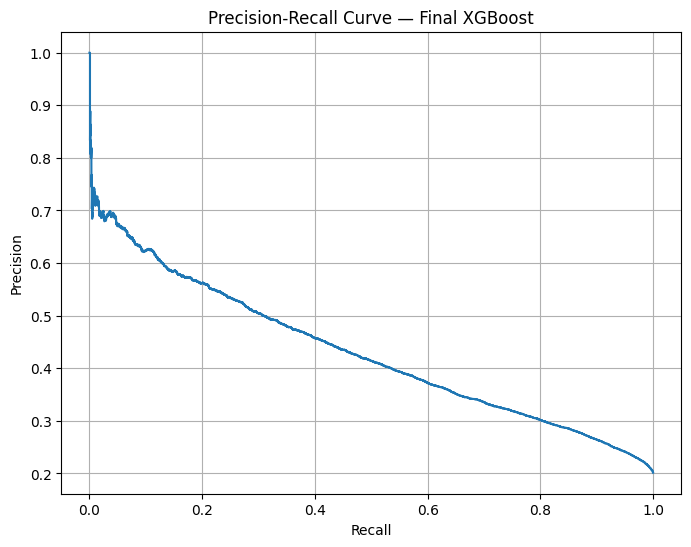

In [23]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# Calculate Precision-Recall values
precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_test_prob_final
)

# Plot Precision-Recall curve
plt.figure(figsize=(8, 6))

plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — Final XGBoost")
plt.grid(True)

plt.show()

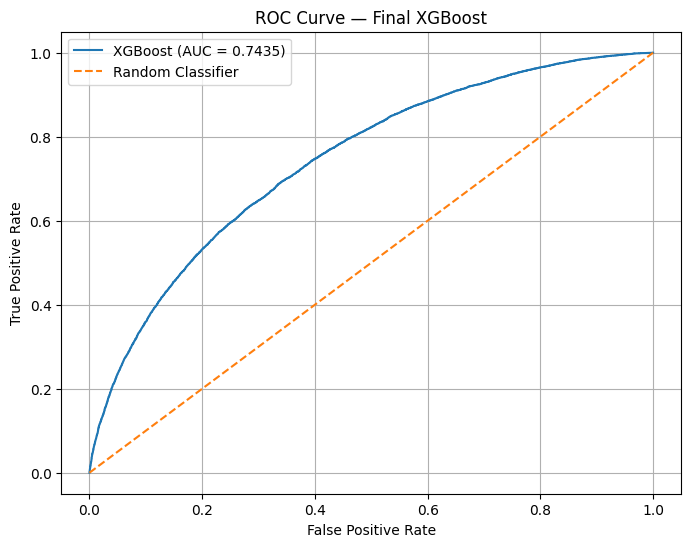

AUC-ROC: 0.7435


In [24]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Calculate ROC values
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_test_prob_final
)

auc_score = roc_auc_score(y_test, y_test_prob_final)

# Plot ROC curve
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f'XGBoost (AUC = {auc_score:.4f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Final XGBoost")
plt.legend()
plt.grid(True)

plt.show()

print(f"AUC-ROC: {auc_score:.4f}")

Top 15 Important Features:
                  Feature  Importance
                  grade_G    0.108900
                  grade_F    0.056606
                  grade_E    0.043733
                  grade_C    0.038101
          term__60_months    0.036690
                 int_rate    0.035612
                  grade_D    0.029150
                  grade_B    0.011746
          fico_range_high    0.009072
             sub_grade_A5    0.008822
      home_ownership_RENT    0.006726
       emp_length_Unknown    0.004933
                 mort_acc    0.004459
  home_ownership_MORTGAGE    0.004323
earliest_cr_line_Jul-2007    0.003225


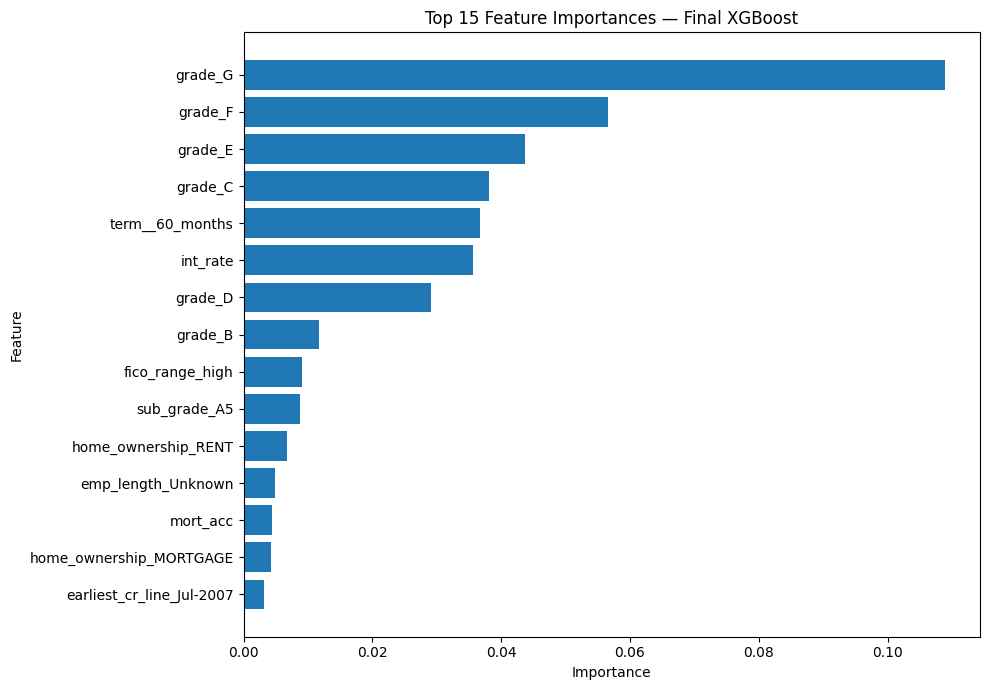

In [25]:
# XGBoost Feature Importance

import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_xgb.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print("Top 15 Important Features:")
print(feature_importance.head(15).to_string(index=False))

# Plot Top 15
top_features = feature_importance.head(15).sort_values(
    by='Importance',
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances — Final XGBoost")

plt.tight_layout()
plt.show()

In [26]:
# Baseline vs Tuned XGBoost Comparison

comparison = pd.DataFrame({
    'Model': ['Baseline XGBoost', 'Tuned XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, y_test_pred),
        accuracy_score(y_test, y_test_pred_final)
    ],
    'Precision': [
        precision_score(y_test, y_test_pred),
        precision_score(y_test, y_test_pred_final)
    ],
    'Recall': [
        recall_score(y_test, y_test_pred),
        recall_score(y_test, y_test_pred_final)
    ],
    'F1-score': [
        f1_score(y_test, y_test_pred),
        f1_score(y_test, y_test_pred_final)
    ],
    'AUC-ROC': [
        roc_auc_score(y_test, y_test_prob),
        roc_auc_score(y_test, y_test_prob_final)
    ]
})

print(comparison.round(4).to_string(index=False))

           Model  Accuracy  Precision  Recall  F1-score  AUC-ROC
Baseline XGBoost    0.8078     0.5904  0.1477    0.2363   0.7446
   Tuned XGBoost    0.8074     0.5803  0.1556    0.2454   0.7435


In [27]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

print("Gradient Boosting model trained successfully.")

Gradient Boosting model trained successfully.


In [28]:
# Gradient Boosting predictions

y_train_pred_gb = gb_model.predict(X_train)
y_test_pred_gb = gb_model.predict(X_test)

# Probability predictions for AUC-ROC
y_test_prob_gb = gb_model.predict_proba(X_test)[:, 1]

print("# Gradient Boosting Performance\n")

print("Training Set:")
print(f"Accuracy : {accuracy_score(y_train, y_train_pred_gb):.4f}")
print(f"Precision: {precision_score(y_train, y_train_pred_gb):.4f}")
print(f"Recall   : {recall_score(y_train, y_train_pred_gb):.4f}")
print(f"F1-score : {f1_score(y_train, y_train_pred_gb):.4f}")

print("\nTesting Set:")
print(f"Accuracy : {accuracy_score(y_test, y_test_pred_gb):.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred_gb):.4f}")
print(f"Recall   : {recall_score(y_test, y_test_pred_gb):.4f}")
print(f"F1-score : {f1_score(y_test, y_test_pred_gb):.4f}")
print(f"AUC-ROC  : {roc_auc_score(y_test, y_test_prob_gb):.4f}")

# Gradient Boosting Performance

Training Set:
Accuracy : 0.8070
Precision: 0.5814
Recall   : 0.1478
F1-score : 0.2357

Testing Set:
Accuracy : 0.8086
Precision: 0.5958
Recall   : 0.1537
F1-score : 0.2444
AUC-ROC  : 0.7445


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import GradientBoostingClassifier

gb_tune = GradientBoostingClassifier(
    random_state=42
)

param_grid_gb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.03, 0.05, 0.1],
    'max_depth': [2, 3, 5],
    'subsample': [0.7, 0.8, 1.0]
}

random_search_gb = RandomizedSearchCV(
    estimator=gb_tune,
    param_distributions=param_grid_gb,
    n_iter=8,
    scoring='f1',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search_gb.fit(X_train, y_train)

print("Best parameters:")
print(random_search_gb.best_params_)

print("\nBest CV F1-score:")
print(random_search_gb.best_score_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
